# Spatial Variation and Influencing Factors of On-Street Parking Occupancy in Downtown Seattle, USA

In [55]:
import time
start_time = time.time()

## Preparation

- [Github link](https://github.com/yjzhou217/CASA0006_final/tree/main) *[Optional]*

- Number of words: 1472

- Runtime: *** hours (*Memory: 16 GB, CPU: Apple M4*)

- Coding environment: VS Code with Conda environment (urbsim, Python 3.12.12)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) 

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - None

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

<div style="line-height: 2.0;">

## 1.0
## Introduction
In high-density city centres, on-street parking provides convenient access to nearby facilities and temporary parking for residents without private spaces, but both over-occupancy and under-use can worsen congestion. 

Existing studies show that parking occupancy varies by time, location and neighbourhood characteristics (Ottosson et al., 2013), that parking use follows identifiable temporal patterns linked to surrounding land-use mix (Kimpton et al., 2023), and that different parking types display spatial differentiation that can be explained by factors such as land use and street networks (Wu and Ma, 2022; Balmer et al., 2021).


[[ go back to the top ]](#Table-of-contents)

<div style="line-height: 2.0;">

## 2.0
## Research questions
This report takes four key paid parking zones in downtown Seattle (**Belltown, First Hill, Commercial Core and Pioneer Square**) as case studies to analyse street-level parking duration patterns, spatial clustering and their influencing factors.

 **RQ 1:** What patterns of time-based usage are evident in on-street paid parking across different streets in Seattle city centre?
 
 **RQ 2:** Do these different parking patterns tend to cluster in certain areas?
 
 **RQ 3:** Which street-level and surrounding built environment factors can explain the variations in on-street paid parking occupancy rates in Seattle’s city centre?

[[ go back to the top ]](#Table-of-contents)

## 3.0 
## Data

| Variable | Type | Description | Notes |
|---|---|---|---|
| Occupied space | Numeric | The number of parking spaces occupied on a street during a given period. | Used for calculating occupancy rate. |
| Parking spaces | Numeric | The number of parking spaces available on a street during a given period. | Used for calculating occupancy rate and as an explanatory variable in RQ3. |
| OccupancyDateTime | Datetime | Timestamp of each parking occupancy record. | Used to derive date, hour, day/night, and weekday/weekend. |
| Period | Categorical | Distinguishes between day and night. |  |
| Weekpart | Categorical | Distinguishes between weekday and weekend. |  |
| Occupancy rate | Numeric | Street-level parking occupancy rate, calculated as occupied spaces divided by total parking spaces. | Core indicator used in RQ1 and RQ2. |
| SourceElementKey | Numeric | Unique identifier for each parking blockface observation. | Used for matching occupancy to street segments. |
| Compkey | Numeric | Unique street segment identifier. | Final street-level analysis unit. |
| BlockfaceName | Text | Name of the parking blockface. |  |
| Onstreet | Text | Street name. | Used in tables and outputs. |
| PaidParkingArea | Categorical | Paid parking area of the blockface. | Study areas: Belltown, Commercial Core, Pioneer Square, and First Hill. |
| PaidParkingSubArea | Categorical | Parking sub-area within the paid parking area. |  |
| Location | Geometry | Point location of each parking observation. | Used for spatial matching to street segments. |
| Four time-specific occupancy indicators | Numeric | Mean street-level parking occupancy rates measured across four time periods: weekday day, weekday night, weekend day, and weekend night. | Used as the input variables for K-means clustering in RQ1. |
| Parking pattern type | Categorical | K-means-derived parking pattern category assigned to each street segment. | Derived in RQ1 and used in RQ2. |
| Same cluster ratio | Numeric | Share of neighbouring street segments that belong to the same cluster. | Used to assess spatial clustering in RQ2. |
| Overall mean occupancy | Numeric | Mean parking occupancy rate of each street segment across all time groups. | Dependent variable in RQ3. |
| Speed limit | Numeric | Mean speed limit by street segment. | Explanatory variable in RQ3. |
| All rate mean ps | Numeric | Mean parking price per street segment from pay station data. | Explanatory variable in RQ3. |
| Commercial mixed share | Numeric | Share of land within the street buffer classified as commercial or mixed use. | Explanatory variable in RQ3. |
| Building coverage ratio | Numeric | Proportion of the 100 ft street buffer covered by building footprints. | Explanatory variable in RQ3. |
| Artdescript | Categorical | Arterial classification of the street segment. | Categorical explanatory variable in RQ3. |
| Paystation count | Numeric | Number of pay stations matched to each street segment. | Explanatory variable in RQ3. |
| Street width | Numeric | Mean width of each street segment. | Explanatory variable in RQ3. |
| Transport parking share | Numeric | Share of land within the street buffer classified as transport or parking-related use. | Explanatory variable in RQ3. |
| One way | Categorical | Whether the street segment is one-way or not. | Categorical explanatory variable in RQ3. |
| Residential share | Numeric | Share of land within the street buffer classified as residential use. | Explanatory variable in RQ3. |

[[ go back to the top ]](#Table-of-contents)

#### 3.1 Packages for running the analysis

In [1]:
# Reading, cleaning, grouping and summarising table data
import pandas as pd
# Reading spatial data, spatial joins
import geopandas as gpd
# Numerical Calculations
import numpy as np
# Plotting and Visualising Results
import matplotlib.pyplot as plt
# Tool for generating basic strings
import string
# Custom colour schemes for map categories
from matplotlib.colors import ListedColormap
# Splitting the training set and test set
from sklearn.model_selection import train_test_split
# Random Forest Regression Model
from sklearn.ensemble import RandomForestRegressor
# Variable Importance and PDP Explanation Plot
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
# Model evaluation metrics
from sklearn.metrics import r2_score, mean_absolute_error
# Standardised variables: z-scores
from sklearn.preprocessing import StandardScaler
# K-means clustering
from sklearn.cluster import KMeans
# Metrics for evaluating clustering performance
from sklearn.metrics import silhouette_score

<div style="line-height: 2.0;">

#### 3.2 Import and load data

Multi-source open data are used, including parking occupancy data from four paid parking zones in March 2025, together with street, pricing, parcel and building data. 

March 2025 was selected because it captures a full weekday–weekend cycle while avoiding seasonal anomalies, and, due to the very short recording intervals, the raw data were downloaded by district and then merged.


In [2]:
# 0. Preparation data
STUDY_NAME = "downtown4"
RAW_DIR = "/Users/ashinxenjier/Downloads/UCL/0006 DS/assessment/Seattle_project_submission/data"
OUT_DIR = "/Users/ashinxenjier/Downloads/UCL/0006 DS/assessment/Seattle_project_submission/output"

RAW_FILES = [
    f"{RAW_DIR}/belltown_march_2025_raw.csv",
    f"{RAW_DIR}/commercial_core_march_2025_raw.csv",
    f"{RAW_DIR}/pioneer_square_march_2025_raw.csv",
    f"{RAW_DIR}/first_hill_march_2025_raw.csv"
]
PAY_STATIONS_CSV = "https://raw.githubusercontent.com/yjzhou217/CASA0006_final/refs/heads/main/data/SDOT_Pay_Stations_-5979592631718995857.csv"
STREETS_ATTR_CSV = "https://raw.githubusercontent.com/yjzhou217/CASA0006_final/refs/heads/main/data/Seattle_Streets_1_-1485582646790599907.csv"

PARCELS_SHP = f"{RAW_DIR}/Zoned_Development_Capacity_Layers_2016-shp/3568c7ec-ce1a-470f-a78e-3efd5886dc192020329-1-x3g6mb.i43zm.shp"
BUILDINGS_SHP = f"{RAW_DIR}/Building_Outlines_2023_-7575316039447773230/Building_Outlines_2023.shp"

DAY_START = 8
DAY_END = 17
MAX_JOIN_DIST = 100
BUFFER_DIST = 100


In [4]:
# 1. Read Seattle street map
streets_url = "https://raw.githubusercontent.com/yjzhou217/CASA0006_final/main/data/Seattle_Streets_1_-7133389635409047574.geojson"
streets = gpd.read_file(streets_url)
streets.columns = [c.strip().lower() for c in streets.columns]

if streets.crs is None:
    streets = streets.set_crs("EPSG:4326")

street_keep = [c for c in ["compkey", "unitdesc", "onstreet", "geometry"] if c in streets.columns]
streets_base = streets[street_keep].copy()

<div style="line-height: 2.0;">

As the time intervals between the original parking records are very short, the dataset is very large. Therefore, the data is downloaded by district and then merged here to combine the four districts.

In [5]:
# 2. Combine the raw data from the four study areas
occ_list = []
for fp in RAW_FILES:
    df = pd.read_csv(fp, low_memory=False)
    occ_list.append(df)
    print(fp, df.shape)

occ = pd.concat(occ_list, ignore_index=True).drop_duplicates().copy()
occ.to_csv(f"{OUT_DIR}/{STUDY_NAME}_march_2025_raw.csv", index=False)

print("Combined raw occ shape:", occ.shape)
print(occ["PaidParkingArea"].value_counts(dropna=False))
print(occ.head())

/Users/ashinxenjier/Downloads/UCL/0006 DS/assessment/Seattle_project_submission/data/belltown_march_2025_raw.csv (4024959, 11)
/Users/ashinxenjier/Downloads/UCL/0006 DS/assessment/Seattle_project_submission/data/commercial_core_march_2025_raw.csv (2034076, 11)
/Users/ashinxenjier/Downloads/UCL/0006 DS/assessment/Seattle_project_submission/data/pioneer_square_march_2025_raw.csv (1150287, 11)
/Users/ashinxenjier/Downloads/UCL/0006 DS/assessment/Seattle_project_submission/data/first_hill_march_2025_raw.csv (2406660, 11)
Combined raw occ shape: (9555132, 11)
PaidParkingArea
Belltown           3984523
First Hill         2397988
Commercial Core    2022334
Pioneer Square     1150287
Name: count, dtype: int64
         OccupancyDateTime  PaidOccupancy  \
0  2025-03-01T08:00:00.000              0   
1  2025-03-01T08:00:00.000              2   
2  2025-03-01T08:00:00.000              1   
3  2025-03-01T08:00:00.000              1   
4  2025-03-01T08:00:00.000              1   

                  

<div style="line-height: 2.0;">

## 4.0 
## Methodology

As the parking occupancy data contain no predefined street types, **unsupervised learning** was used to identify patterns. Raw observations were cleaned and aggregated to street-segment level, and occupancy rates for four time periods were calculated to capture temporal demand variation linked to surrounding land use (Ottosson et al., 2013; Kimpton et al., 2023). **K-means clustering**, supported by the elbow method and silhouette score, was then used to define street types (Wu and Ma, 2022).

These types were further examined through neighbourhood consistency analysis to test **spatial clustering**. To explain variation in overall street occupancy, several variables were incorporated into a **Random Forest regression model**, which is suited to non-linear relationships and complex spatial characteristics (Balmer et al., 2021). **Permutation Importance** and **Partial Dependence Plots** were used to interpret the main factors and their effects.

[[ go back to the top ]](#Table-of-contents)

#### 4.1 Data cleaning

In [6]:
# 3. Basic cleaning
occ["OccupancyDateTime"] = pd.to_datetime(occ["OccupancyDateTime"], errors="coerce")
occ["PaidOccupancy"] = pd.to_numeric(occ["PaidOccupancy"], errors="coerce")
occ["ParkingSpaceCount"] = pd.to_numeric(occ["ParkingSpaceCount"], errors="coerce")

occ = occ.dropna(subset=["OccupancyDateTime", "PaidOccupancy", "ParkingSpaceCount"]).copy()
occ = occ[occ["ParkingSpaceCount"] > 0].copy()

In [7]:
# 4. Extract the date, hour and the hour on the hour
occ["date"] = occ["OccupancyDateTime"].dt.date
occ["hour"] = occ["OccupancyDateTime"].dt.hour
occ["date_hour"] = occ["OccupancyDateTime"].dt.floor("h")

#### 4.2 Calculate key indicators

In [8]:
# 5. Core indicators
occ["occupied_spaces"] = occ["PaidOccupancy"]
occ["parking_spaces"] = occ["ParkingSpaceCount"]
occ["occupancy_rate"] = occ["PaidOccupancy"] / occ["ParkingSpaceCount"]
occ["occupancy_rate"] = occ["occupancy_rate"].clip(lower=0, upper=1)

In [9]:
# 6. mode_safe
def mode_safe(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

In [10]:
# 7. Generate a 'Daily by Hour' table
hourly_occ_table = (
    occ.groupby(
        [
            "SourceElementKey",
            "BlockfaceName",
            "PaidParkingArea",
            "PaidParkingSubArea",
            "date",
            "hour",
            "date_hour"
        ],
        dropna=False
    )
    .agg(
        occupied_spaces=("occupied_spaces", "mean"),
        parking_spaces=("parking_spaces", "median"),
        occupancy_rate=("occupancy_rate", "mean"),
        n_obs=("occupancy_rate", "size"),
        paid_rate=("PaidParkingRate", mode_safe),
        time_limit=("ParkingTimeLimitCategory", mode_safe),
        parking_category=("ParkingCategory", mode_safe)
    )
    .reset_index()
)


In [11]:
# 8. Day and Night label
hourly_occ_table["period"] = np.where(
    hourly_occ_table["hour"].between(8, 17),
    "day",
    "night"
)

# 9. Weekday and Weekend label
hourly_occ_table["date"] = pd.to_datetime(hourly_occ_table["date"])
hourly_occ_table["weekpart"] = np.where(
    hourly_occ_table["date"].dt.weekday < 5,
    "weekday",
    "weekend"
)

## 5.0 
## Results and discussion

[[ go back to the top ]](#Table-of-contents)

<div style="line-height: 2.0;">

#### 5.1 Spatial distribution of parking space occupancy types

- **Under-staturated:** many vacant on-street parking spaces, low utilisation, block traffic lanes
- **Over-staturated:** cause traffic congestion
- **Optimal:** most effectively

**5.1.1 Classified by policy**

- **below 70%** = under-saturated
- **70%–85%** = optimal
- **above 85%** = over-saturated (SDOT, 2024)

In [12]:
# 11. join space to streets
loc_extract = occ["Location"].astype(str).str.extract(
    r"POINT\s*\(\s*([-\d\.]+)\s+([-\d\.]+)\s*\)"
)

occ["longitude"] = pd.to_numeric(loc_extract[0], errors="coerce")
occ["latitude"] = pd.to_numeric(loc_extract[1], errors="coerce")

occ_geo = occ.dropna(subset=["latitude", "longitude"]).copy()

occ_gdf = gpd.GeoDataFrame(
    occ_geo,
    geometry=gpd.points_from_xy(occ_geo["longitude"], occ_geo["latitude"]),
    crs="EPSG:4326"
)

occ_gdf = occ_gdf.to_crs(epsg=2285)
streets_base = streets_base.to_crs(epsg=2285)

occ_street_join = gpd.sjoin_nearest(
    occ_gdf,
    streets_base,
    how="left",
    distance_col="dist_to_street"
)

occ_street_join = occ_street_join[occ_street_join["dist_to_street"] <= MAX_JOIN_DIST].copy()


In [13]:
# 12. Generate a mapping table for SourceElementKey to street
source_to_street = (
    occ_street_join.groupby("SourceElementKey", dropna=False)
    .agg(
        compkey=("compkey", mode_safe),
        unitdesc=("unitdesc", mode_safe),
        onstreet=("onstreet", mode_safe),
        blockface_name=("BlockfaceName", mode_safe)
    )
    .reset_index()
)


In [14]:
# 13. Merge the hourly table with the street mapping
hourly_occ_street = hourly_occ_table.merge(
    source_to_street,
    on="SourceElementKey",
    how="left"
)

hourly_occ_street = hourly_occ_street.dropna(subset=["compkey"]).copy()


In [15]:
# 14. Aggregated Market Share Table at Street Level
street_occ_table = (
    hourly_occ_street.groupby(
        [
            "compkey",
            "unitdesc",
            "onstreet",
            "blockface_name",
            "period",
            "weekpart"
        ],
        dropna=True
    )
    .agg(
        occupancy_rate=("occupancy_rate", "mean"),
        occupied_spaces=("occupied_spaces", "mean"),
        parking_spaces=("parking_spaces", "median"),
        n_hours=("date_hour", "nunique"),
        n_obs=("n_obs", "sum"),
        paid_rate=("paid_rate", mode_safe),
        time_limit=("time_limit", mode_safe),
        parking_category=("parking_category", mode_safe),
        paid_subarea=("PaidParkingSubArea", mode_safe)
    )
    .reset_index()
)

street_occ_table["occupancy_class"] = np.select(
    [
        street_occ_table["occupancy_rate"] < 0.70,
        (street_occ_table["occupancy_rate"] >= 0.70) & (street_occ_table["occupancy_rate"] <= 0.85),
        street_occ_table["occupancy_rate"] > 0.85
    ],
    [
        "Under-saturated",
        "Optimal",
        "Over-saturated"
    ],
    default="Unknown"
)

street_occ_table.to_csv(
    f"{OUT_DIR}/{STUDY_NAME}_march_2025_street_occupancy_daynight_weekdayweekend.csv",
    index=False
)


In [16]:
# 15. join to map
street_map = streets_base.merge(
    street_occ_table,
    on="compkey",
    how="left"
)

In [17]:
# 16. Export the four map layers separately by category
day_weekday_map = street_map[
    (street_map["period"] == "day") & (street_map["weekpart"] == "weekday")
].copy()

day_weekend_map = street_map[
    (street_map["period"] == "day") & (street_map["weekpart"] == "weekend")
].copy()

night_weekday_map = street_map[
    (street_map["period"] == "night") & (street_map["weekpart"] == "weekday")
].copy()

night_weekend_map = street_map[
    (street_map["period"] == "night") & (street_map["weekpart"] == "weekend")
].copy()

day_weekday_map.to_file(
    f"{OUT_DIR}/{STUDY_NAME}_day_weekday_occupancy_map.geojson",
    driver="GeoJSON"
)
day_weekend_map.to_file(
    f"{OUT_DIR}/{STUDY_NAME}_day_weekend_occupancy_map.geojson",
    driver="GeoJSON"
)
night_weekday_map.to_file(
    f"{OUT_DIR}/{STUDY_NAME}_night_weekday_occupancy_map.geojson",
    driver="GeoJSON"
)
night_weekend_map.to_file(
    f"{OUT_DIR}/{STUDY_NAME}_night_weekend_occupancy_map.geojson",
    driver="GeoJSON"
)

<div style="line-height: 2.0;">

**5.1.1.A. Figure 1,2,3,4 | Four street coverage maps**

There are marked temporal and spatial variations in the occupancy rates in Seattle’s city centre. 

Overall, occupancy rates are higher at night and at weekends than during the day and on weekdays, with high-occupancy sections primarily concentrated near the waterfront, in bustling commercial areas and along certain main thoroughfares; by contrast, occupancy remains consistently low at all times of day on some peripheral streets, indicating under-utilisation.

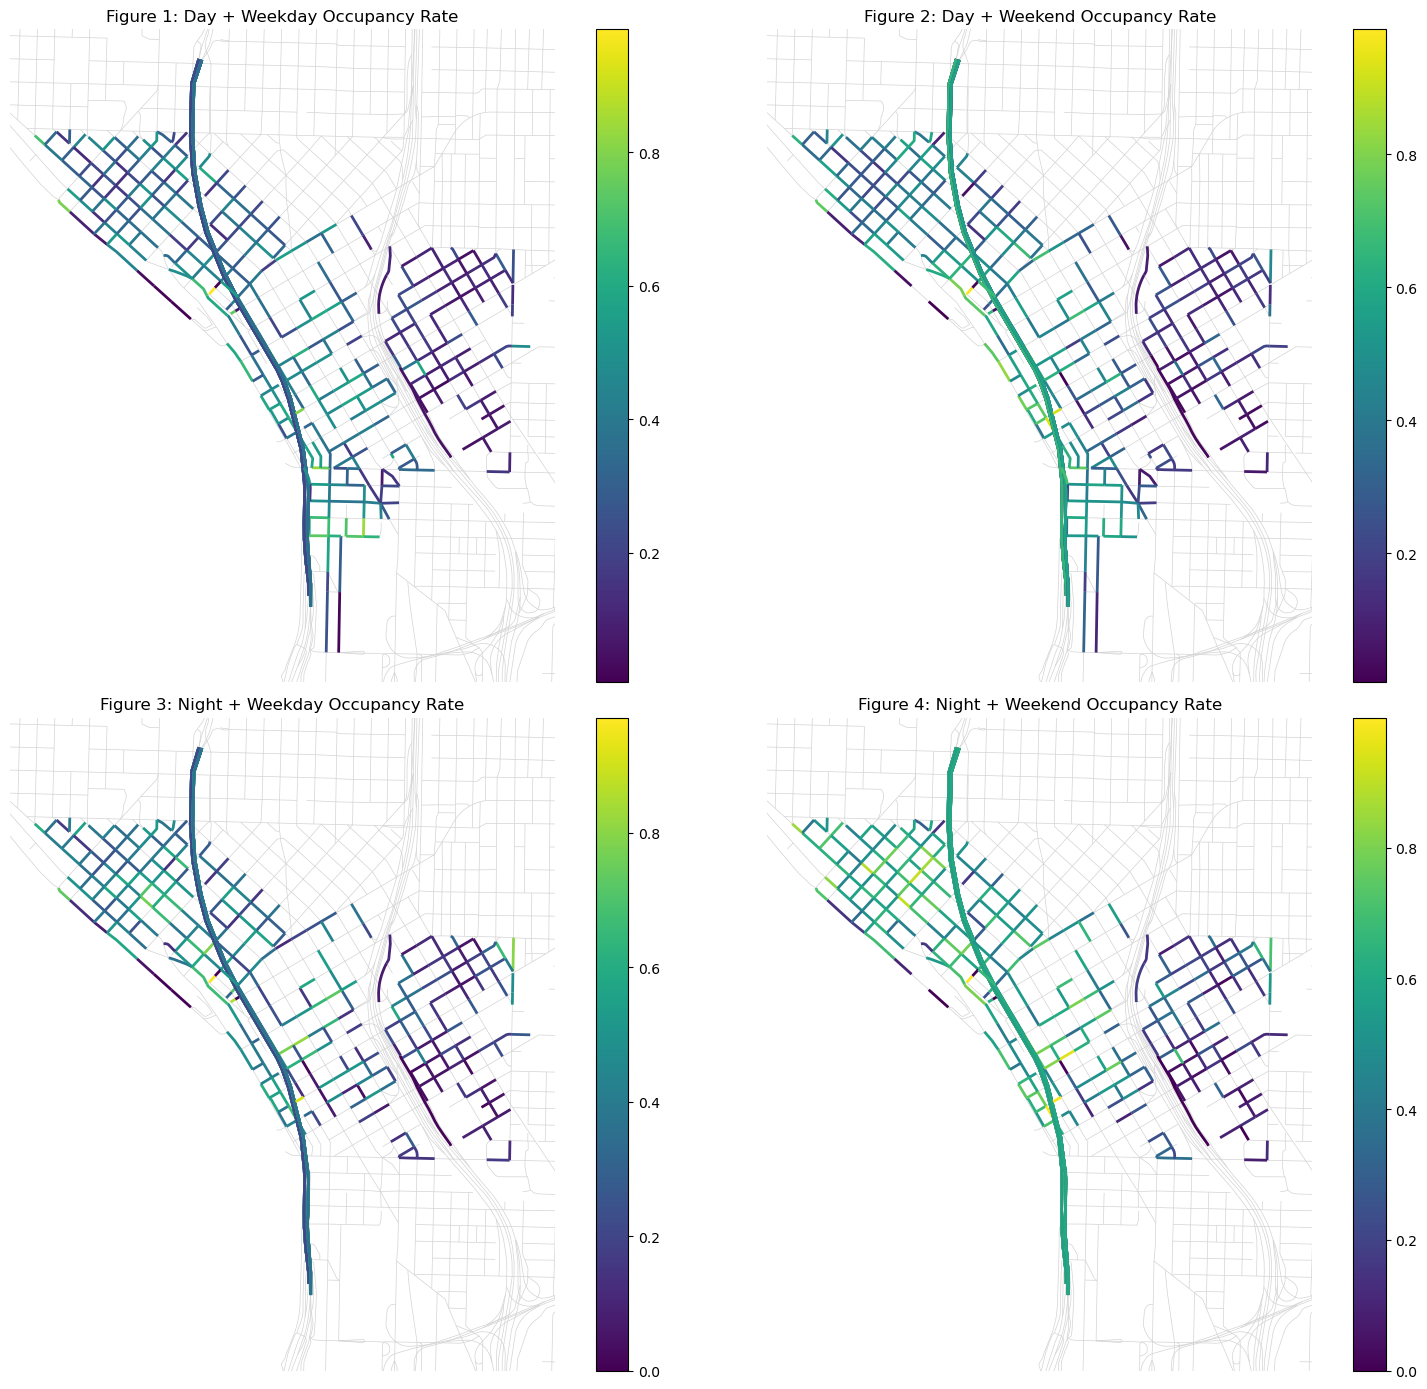

In [18]:
# 17. Draw four street coverage maps
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Calculating the boundaries of the study area (shared across four maps)
plot_union = pd.concat([
    day_weekday_map.dropna(subset=["occupancy_rate"]),
    day_weekend_map.dropna(subset=["occupancy_rate"]),
    night_weekday_map.dropna(subset=["occupancy_rate"]),
    night_weekend_map.dropna(subset=["occupancy_rate"])
], ignore_index=False)

xmin, ymin, xmax, ymax = plot_union.total_bounds
xpad = (xmax - xmin) * 0.05
ypad = (ymax - ymin) * 0.05

streets_base.plot(ax=axes[0, 0], color="lightgrey", linewidth=0.5)
day_weekday_map.dropna(subset=["occupancy_rate"]).plot(
    ax=axes[0, 0], column="occupancy_rate", linewidth=2, legend=True
)
axes[0, 0].set_title("Figure 1: Day + Weekday Occupancy Rate")
axes[0, 0].axis("off")

streets_base.plot(ax=axes[0, 1], color="lightgrey", linewidth=0.5)
day_weekend_map.dropna(subset=["occupancy_rate"]).plot(
    ax=axes[0, 1], column="occupancy_rate", linewidth=2, legend=True
)
axes[0, 1].set_title("Figure 2: Day + Weekend Occupancy Rate")
axes[0, 1].axis("off")

streets_base.plot(ax=axes[1, 0], color="lightgrey", linewidth=0.5)
night_weekday_map.dropna(subset=["occupancy_rate"]).plot(
    ax=axes[1, 0], column="occupancy_rate", linewidth=2, legend=True
)
axes[1, 0].set_title("Figure 3: Night + Weekday Occupancy Rate")
axes[1, 0].axis("off")

streets_base.plot(ax=axes[1, 1], color="lightgrey", linewidth=0.5)
night_weekend_map.dropna(subset=["occupancy_rate"]).plot(
    ax=axes[1, 1], column="occupancy_rate", linewidth=2, legend=True
)
axes[1, 1].set_title("Figure 4: Night + Weekend Occupancy Rate")
axes[1, 1].axis("off")

for ax in axes.flat:
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

plt.tight_layout()
plt.show()

<div style="line-height: 2.0;">

**5.1.1.B. Figure 5 | Number of Streets by 4-Period Occupancy Class**

Figure 5 helps to determine whether on-street parking in Seattle’s city centre is primarily dominated by a small number of typical usage patterns.

The results show that the vast majority of streets fall into Category A (undersaturated). City centre is predominantly characterised by streets with low occupancy.

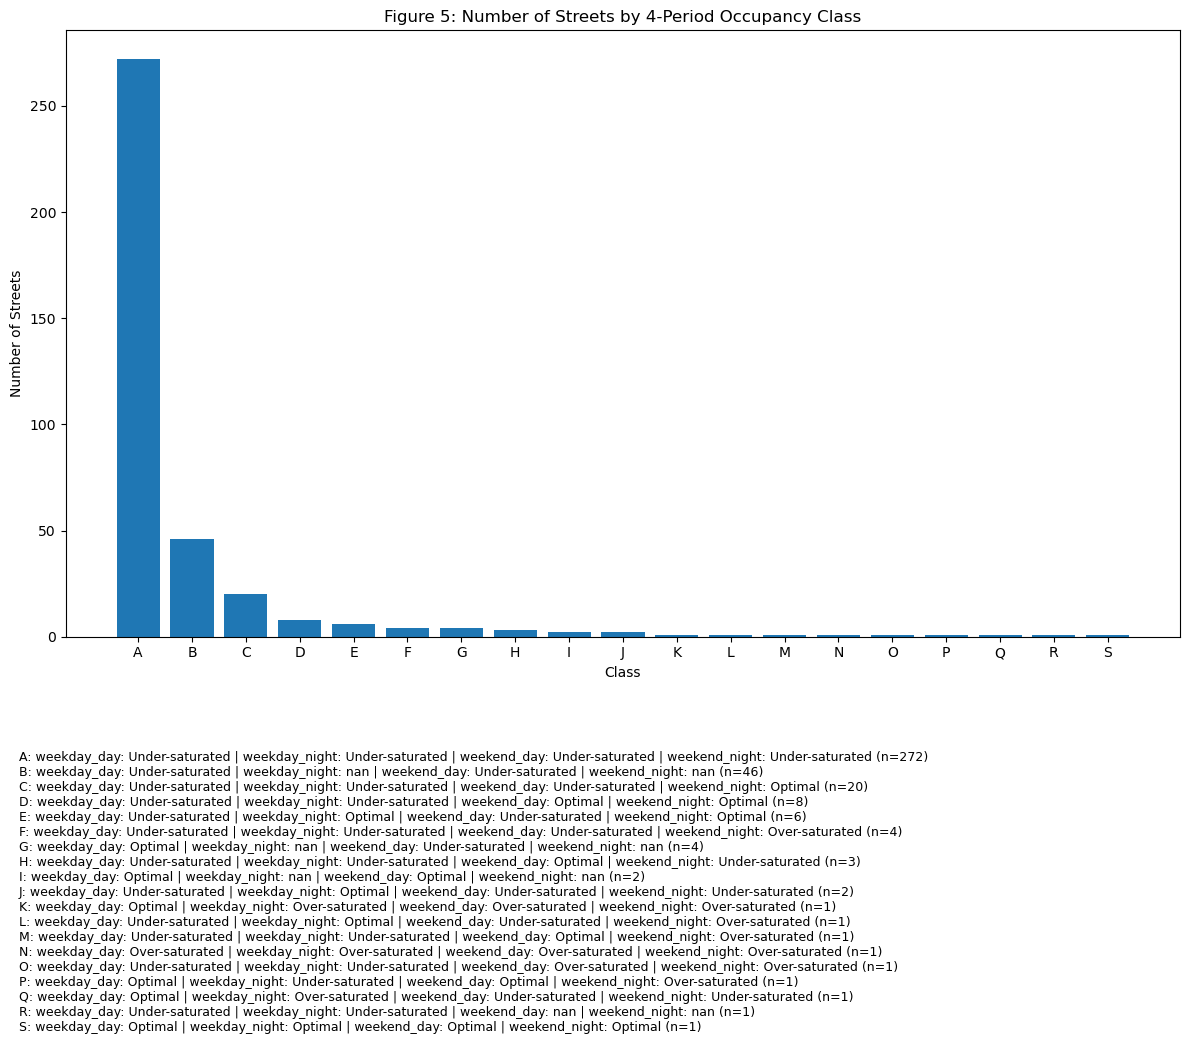

In [19]:
# 18. RQ1: Four-period combination classification table
street_occ_table["time_group"] = street_occ_table["weekpart"] + "_" + street_occ_table["period"]

street_class_wide = street_occ_table.pivot_table(
    index=["compkey", "unitdesc", "onstreet", "blockface_name"],
    columns="time_group",
    values="occupancy_class",
    aggfunc="first"
).reset_index()

expected_cols = ["weekday_day", "weekday_night", "weekend_day", "weekend_night"]
for c in expected_cols:
    if c not in street_class_wide.columns:
        street_class_wide[c] = np.nan

street_class_wide = street_class_wide[
    [
        "compkey", "unitdesc", "onstreet", "blockface_name",
        "weekday_day", "weekday_night", "weekend_day", "weekend_night"
    ]
].copy()

street_class_wide["combo_class"] = (
    "weekday_day " + street_class_wide["weekday_day"].astype(str) + " | " +
    "weekday_night " + street_class_wide["weekday_night"].astype(str) + " | " +
    "weekend_day " + street_class_wide["weekend_day"].astype(str) + " | " +
    "weenend_night: " + street_class_wide["weekend_night"].astype(str)
)

street_class_wide.to_csv(
    f"{OUT_DIR}/{STUDY_NAME}_street_4period_occupancy_class_table.csv",
    index=False
)



combo_with_streets = (
    street_class_wide.groupby(
        ["weekday_day", "weekday_night", "weekend_day", "weekend_night"],
        dropna=False
    )
    .agg(
        n_streets=("compkey", "nunique"),
        street_codes=("compkey", lambda x: ", ".join(map(str, sorted(x.dropna().unique())))),
        street_names=("unitdesc", lambda x: " || ".join(sorted(x.dropna().unique())))
    )
    .reset_index()
)

combo_with_streets["combo_label"] = (
    "weekday_day: " + combo_with_streets["weekday_day"].astype(str) + " | " +
    "weekday_night: " + combo_with_streets["weekday_night"].astype(str) + " | " +
    "weekend_day: " + combo_with_streets["weekend_day"].astype(str) + " | " +
    "weekend_night: " + combo_with_streets["weekend_night"].astype(str)
)

combo_with_streets = combo_with_streets[
    [
        "combo_label",
        "weekday_day", "weekday_night", "weekend_day", "weekend_night",
        "n_streets", "street_codes", "street_names"
    ]
].sort_values("n_streets", ascending=False).reset_index(drop=True)

combo_with_streets.to_csv(
    f"{OUT_DIR}/{STUDY_NAME}_street_occupancy_combo_with_streets.csv",
    index=False
)

plot_df = combo_with_streets.sort_values("n_streets", ascending=False).reset_index(drop=True).copy()
letters = list(string.ascii_uppercase)
plot_df["class_code"] = letters[:len(plot_df)]

class_lookup = plot_df[["class_code", "combo_label", "n_streets"]].copy()
class_lookup.to_csv(f"{OUT_DIR}/{STUDY_NAME}_combo_class_lookup.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(plot_df["class_code"], plot_df["n_streets"])
ax.set_xlabel("Class")
ax.set_ylabel("Number of Streets")
ax.set_title("Figure 5: Number of Streets by 4-Period Occupancy Class")

lookup_text = "\n".join(
    [f"{row.class_code}: {row.combo_label} (n={row.n_streets})"
     for _, row in class_lookup.iterrows()]
)

fig.text(
    0.02, -0.08,
    lookup_text,
    ha="left",
    va="top",
    fontsize=9
)

plt.tight_layout()
plt.show()


<div style="line-height: 2.0;">

**5.1.1.C. Figure 6,7 | Distribution of occupancy rates for streets under-statured in all four periods**

Figure 6,7 provide a more intuitive representation of the median, degree of dispersion and the range of variation across individual streets than bar charts.

Even among streets classified as underutilised across all four time periods, occupancy rates on weekend nights remain significantly higher overall than during the other three periods, whilst rates during other three periods are similar. This suggests that, there is still a relatively stronger demand for parking at night and at weekends.

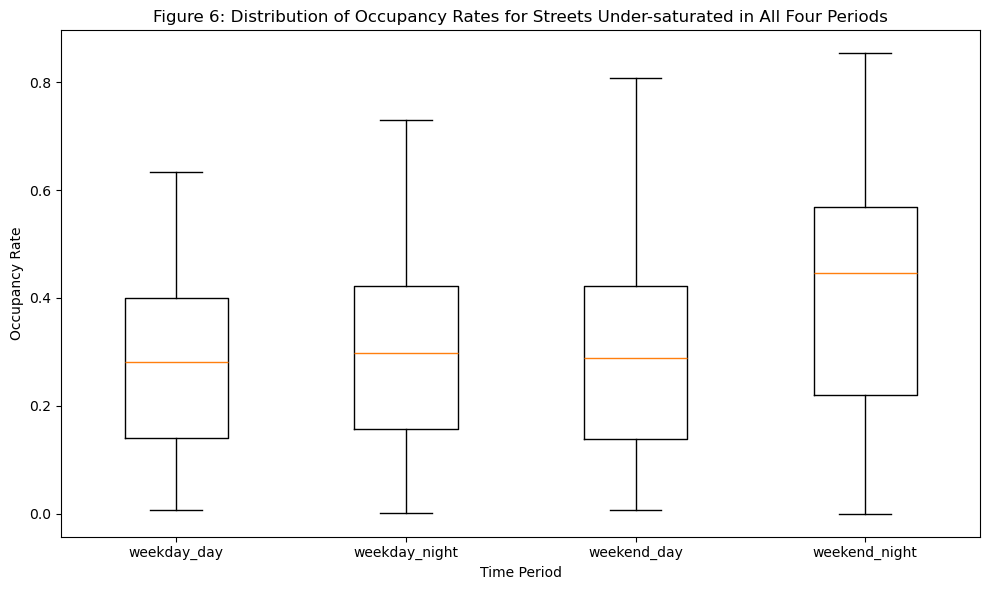

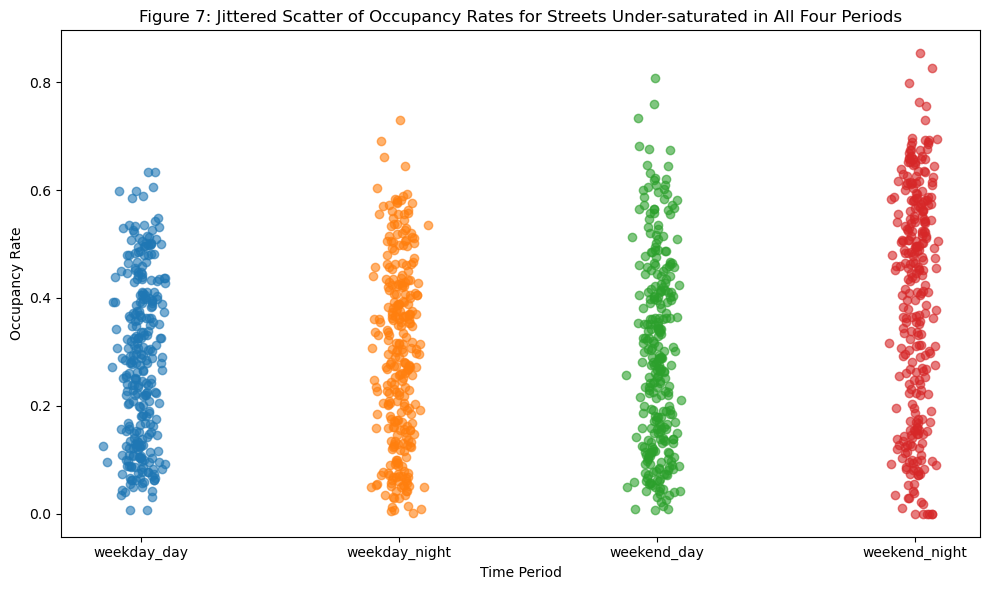

In [20]:
# 19. Distribution of streets with below-saturation levels across the four time periods
all_under = street_class_wide[
    (street_class_wide["weekday_day"] == "Under-saturated") &
    (street_class_wide["weekday_night"] == "Under-saturated") &
    (street_class_wide["weekend_day"] == "Under-saturated") &
    (street_class_wide["weekend_night"] == "Under-saturated")
].copy()

under_compkeys = all_under["compkey"].dropna().unique()

under_dist = street_occ_table[
    street_occ_table["compkey"].isin(under_compkeys)
].copy()

under_dist["time_group"] = under_dist["weekpart"] + "_" + under_dist["period"]

order = ["weekday_day", "weekday_night", "weekend_day", "weekend_night"]

plot_data = [
    under_dist.loc[under_dist["time_group"] == g, "occupancy_rate"].dropna()
    for g in order
]

plt.figure(figsize=(10, 6))
plt.boxplot(plot_data, tick_labels=order)
plt.ylabel("Occupancy Rate")
plt.xlabel("Time Period")
plt.title("Figure 6: Distribution of Occupancy Rates for Streets Under-saturated in All Four Periods")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for i, g in enumerate(order, start=1):
    y = under_dist.loc[under_dist["time_group"] == g, "occupancy_rate"].dropna().values
    x = np.random.normal(i, 0.04, size=len(y))
    plt.scatter(x, y, alpha=0.6)

plt.xticks(range(1, len(order) + 1), order)
plt.ylabel("Occupancy Rate")
plt.xlabel("Time Period")
plt.title("Figure 7: Jittered Scatter of Occupancy Rates for Streets Under-saturated in All Four Periods")
plt.tight_layout()
plt.show()

<div style="line-height: 2.0;">

**5.1.2 Classified by K-means**

K-means clustering was first employed to identify data-driven types of street performance prior to spatial analysis, in order to ascertain whether a more natural grouping structure existed within the sample.

- Sample unit: compkey 
- Clustering variable: occupancy_rate across 4 time periods 
- Standardisation: Z-score 
- Selecting k: elbow method + silhouette score

In [21]:
# 20. K-means clustering
# 20.1. Construct the K-means input table: one row per street, with the occupancy_rate for four time periods
street_kmeans_wide = street_occ_table.pivot_table(
    index=["compkey", "unitdesc", "onstreet", "blockface_name"],
    columns="time_group",
    values="occupancy_rate",
    aggfunc="mean"
).reset_index()

kmeans_vars = ["weekday_day", "weekday_night", "weekend_day", "weekend_night"]
for c in kmeans_vars:
    if c not in street_kmeans_wide.columns:
        street_kmeans_wide[c] = np.nan

street_kmeans = street_kmeans_wide.dropna(subset=kmeans_vars).copy()


In [22]:
# 20.2. Z-score standardization
X = street_kmeans[kmeans_vars].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
# 20.3. Selecting k: the elbow method + silhouette score
#    Prioritise trying k = 2 to 6
k_values = range(2, 7)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

**5.1.2.A Figure 8 | Elbow Method for K-means**

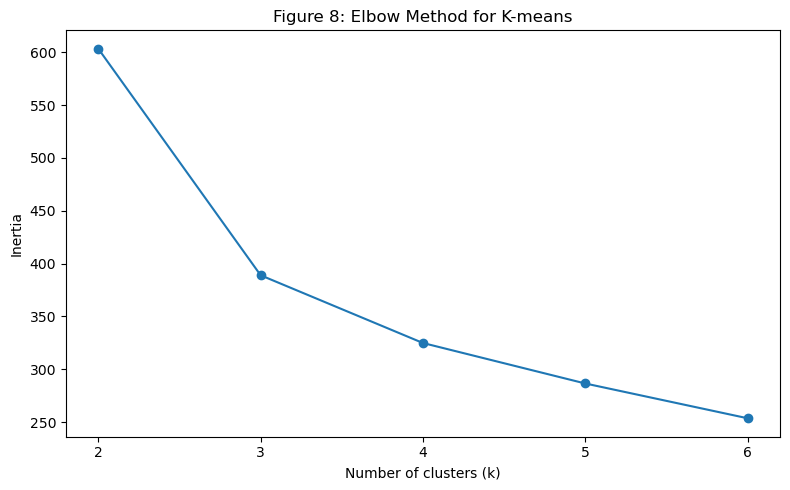

In [24]:
# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Figure 8: Elbow Method for K-means")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

<div style="line-height: 2.0;">

**5.1.2.B Figure 9 | Silhouette Score for K-means**

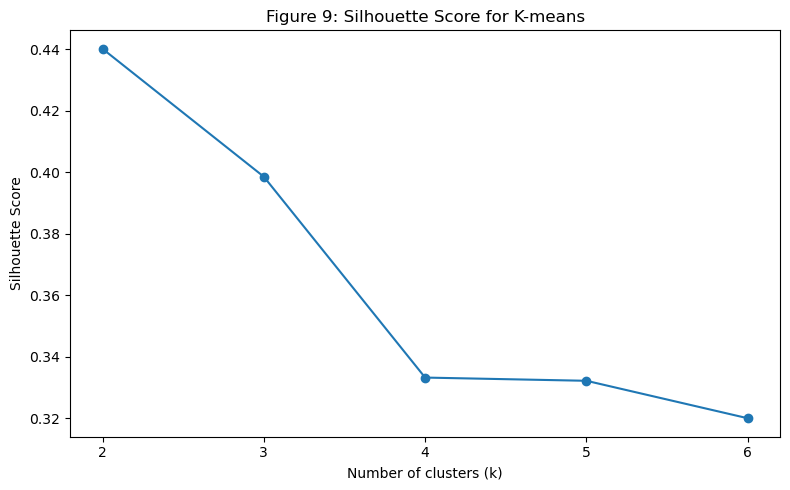

In [25]:
# Silhouette plot
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Figure 9: Silhouette Score for K-means")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

In [26]:
# Print the results of k
k_eval = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": sil_scores
})
print(k_eval)

   k     inertia  silhouette_score
0  2  603.203362          0.440191
1  3  388.971349          0.398559
2  4  324.898151          0.333193
3  5  286.616779          0.332144
4  6  253.724732          0.319953


<div style="line-height: 2.0;">

Figures 8 and 9 were used together to determine the most appropriate number of clusters in the K-means analysis. 

Although the silhouette score is highest at k=2, the elbow method shows the largest drop in intra-class variance between k=2 and k=3, after which improvement slows markedly, while k=3 still retains a relatively high silhouette score (0.399); therefore, this study adopts a **three-cluster** solution.

In [27]:
# 20.4. use k=3 to run the model
best_k = 3

kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
street_kmeans["cluster"] = kmeans_model.fit_predict(X_scaled)

In [28]:
# 20.5. View the raw mean for each cluster
cluster_profile = (
    street_kmeans.groupby("cluster")[kmeans_vars]
    .mean()
    .reset_index()
)

print(cluster_profile)

time_group  cluster  weekday_day  weekday_night  weekend_day  weekend_night
0                 0     0.307138       0.330487     0.334810       0.484142
1                 1     0.127688       0.121523     0.105240       0.147964
2                 2     0.510171       0.553342     0.581477       0.692860


In [29]:
# 20.6. Manually naming clusters based on four-time-period profiles
cluster_profile["overall_mean"] = cluster_profile[kmeans_vars].mean(axis=1)

cluster_name_map = {}

# First, identify the ‘overall minimum’ and the ‘overall maximum’
lowest_cluster = cluster_profile.loc[cluster_profile["overall_mean"].idxmin(), "cluster"]
highest_cluster = cluster_profile.loc[cluster_profile["overall_mean"].idxmax(), "cluster"]

cluster_name_map[lowest_cluster] = "Consistently low occupancy streets"
cluster_name_map[highest_cluster] = "Consistently high occupancy streets"

# For the remaining clusters, we will then examine the day/night and weekday/weekend features
remaining_clusters = [c for c in cluster_profile["cluster"] if c not in [lowest_cluster, highest_cluster]]

for c in remaining_clusters:
    row = cluster_profile.loc[cluster_profile["cluster"] == c].iloc[0]

    day_mean = np.mean([row["weekday_day"], row["weekend_day"]])
    night_mean = np.mean([row["weekday_night"], row["weekend_night"]])
    weekday_mean = np.mean([row["weekday_day"], row["weekday_night"]])
    weekend_mean = np.mean([row["weekend_day"], row["weekend_night"]])

    if day_mean > night_mean:
        cluster_name_map[c] = "Daytime-active streets"
    elif (night_mean > day_mean) or (weekend_mean > weekday_mean):
        cluster_name_map[c] = "Night/weekend intensive streets"
    else:
        cluster_name_map[c] = f"Cluster {c}"

street_kmeans["cluster_label"] = street_kmeans["cluster"].map(cluster_name_map)

<div style="line-height: 2.0;">

**5.1.2.C Figure 10 | Distribution of Four-Period Occupancy by Cluster**

Figure 10 is used to verify whether the three categories of streets identified by the K-means algorithm exhibit genuine and interpretable temporal differences, rather than merely being the result of algorithmic grouping.

The differences between the three categories of streets are clear: green streets consistently fall within the lowest range across all four time periods, reflecting persistently low occupancy; orange streets show generally higher levels across all four periods, indicating persistently high occupancy; blue streets exhibit lower occupancy during weekday daytime hours but rise significantly at night and at weekends, demonstrating stronger demand during these periods. 

Consequently, the clustering results not only distinguish between high and low occupancy levels but also identify distinct temporal usage patterns across different streets.

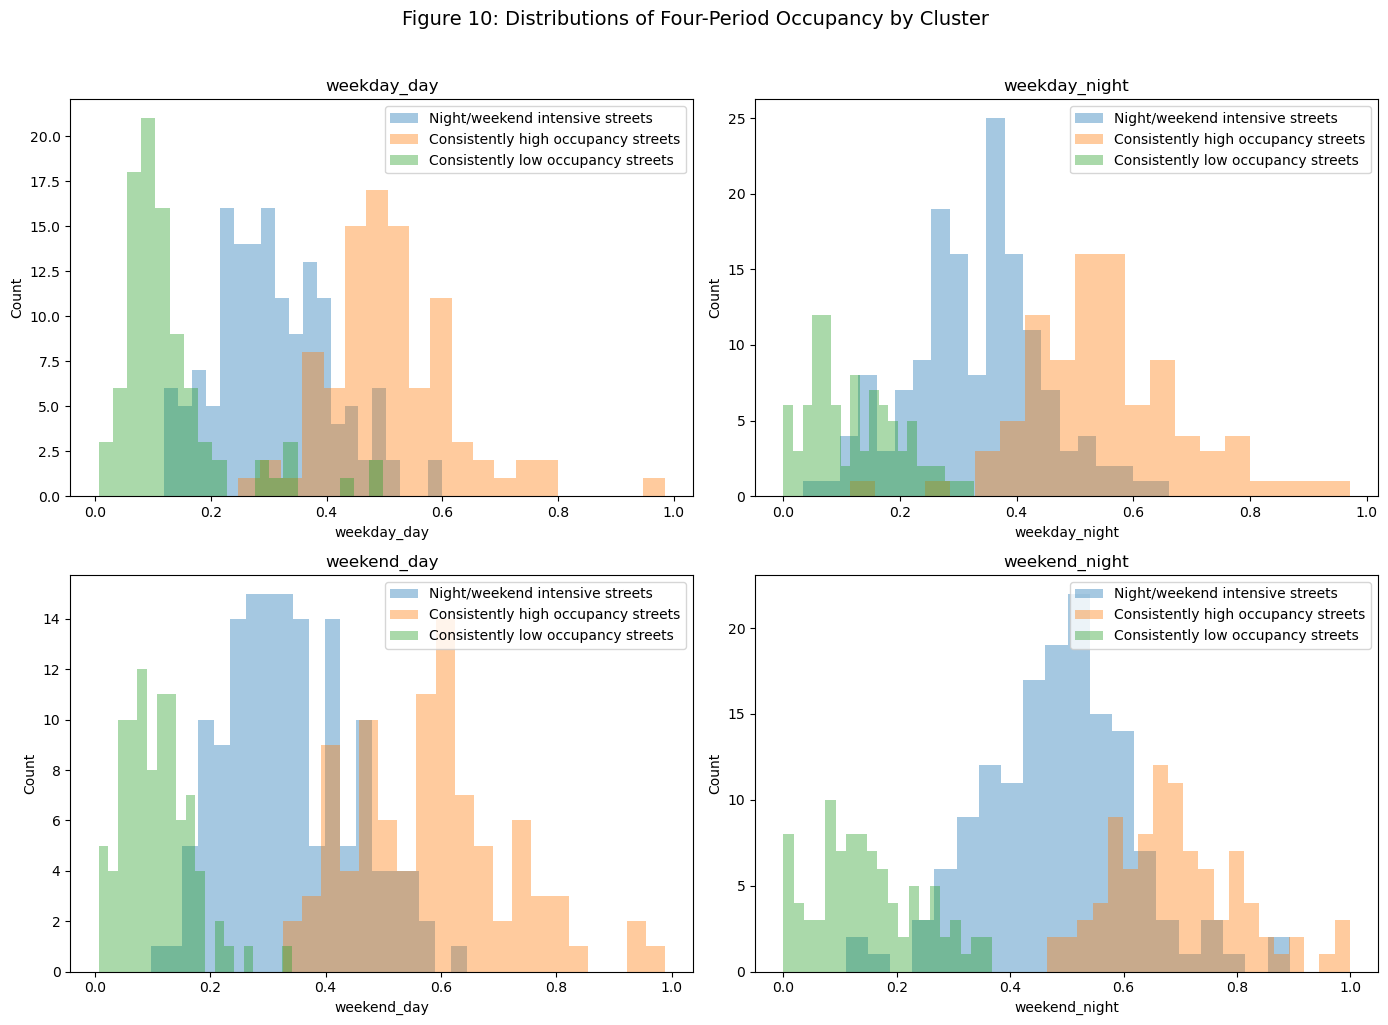

In [30]:
# 20.6.1 Cluster distributions of four-period occupancy
plot_vars_core = ["weekday_day", "weekday_night", "weekend_day", "weekend_night"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(plot_vars_core):
    ax = axes[i]
    for label in street_kmeans["cluster_label"].dropna().unique():
        street_kmeans.loc[
            street_kmeans["cluster_label"] == label, var
        ].dropna().plot(
            kind="hist",
            bins=20,
            alpha=0.4,
            ax=ax,
            label=label
        )
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Figure 10: Distributions of Four-Period Occupancy by Cluster", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
# 20.7. Output the final classification table
street_kmeans_result = street_kmeans[
    ["compkey", "unitdesc", "onstreet", "blockface_name"] + kmeans_vars + ["cluster", "cluster_label"]
].copy()

street_kmeans_result.to_csv(
    f"{RAW_DIR}/{STUDY_NAME}_street_kmeans_clusters_k3.csv",
    index=False
)

cluster_profile["cluster_label"] = cluster_profile["cluster"].map(cluster_name_map)
cluster_profile.to_csv(
    f"{RAW_DIR}/{STUDY_NAME}_kmeans_cluster_profiles_k3.csv",
    index=False
)


#### 5.2 Do these types exhibit spatial clustering?

<div style="line-height: 2.0;">

**5.2.A Figure 11 | K-means Clustering of Downtown Seattle Street Occupancy Patterns (k=3)**

Figure 11 shows that these three types exhibit certain patterns of spatial clustering: the green ones are mainly distributed in a continuous pattern along the waterfront and some major thoroughfares, the purple ones are concentrated on the eastern fringe, whilst the yellow ones are found predominantly in the transitional zone between the two.

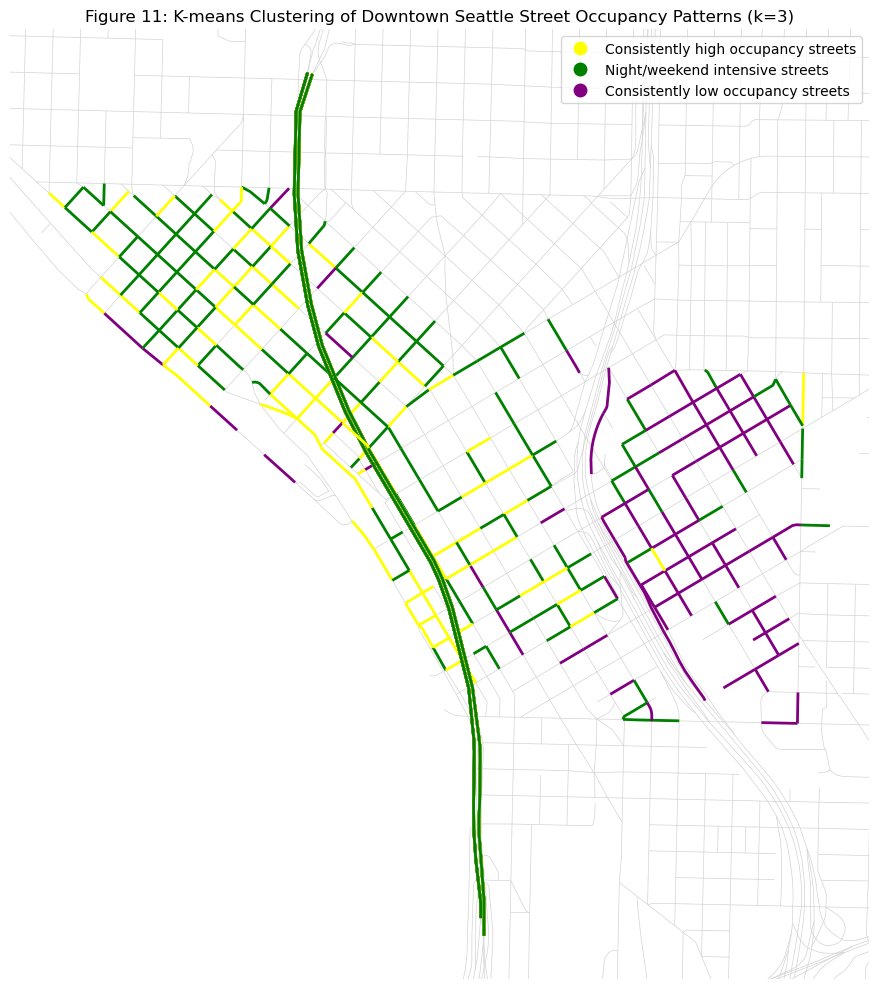

In [32]:
# =========================================================
# 21. K-means map
# =========================================================
street_kmeans_map = streets_base.merge(
    street_kmeans_result[["compkey", "cluster", "cluster_label"]],
    on="compkey",
    how="left"
)

street_kmeans_map.to_file(
    f"{OUT_DIR}/{STUDY_NAME}_street_kmeans_clusters_k3.geojson",
    driver="GeoJSON"
)

fig, ax = plt.subplots(figsize=(10, 10))

plot_gdf = street_kmeans_map.dropna(subset=["cluster_label"]).copy()

xmin, ymin, xmax, ymax = plot_gdf.total_bounds
xpad = (xmax - xmin) * 0.05
ypad = (ymax - ymin) * 0.05

streets_base.plot(ax=ax, color="lightgrey", linewidth=0.5)

cat_order = [
    "Consistently high occupancy streets",
    "Night/weekend intensive streets",
    "Consistently low occupancy streets"
]

plot_gdf["cluster_label"] = pd.Categorical(
    plot_gdf["cluster_label"],
    categories=cat_order,
    ordered=True
)

cmap = ListedColormap(["yellow", "green", "purple"])

plot_gdf.plot(
    ax=ax,
    column="cluster_label",
    linewidth=2,
    legend=True,
    categorical=True,
    cmap=cmap
)

ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

ax.set_title("Figure 11: K-means Clustering of Downtown Seattle Street Occupancy Patterns (k=3)")
ax.axis("off")
plt.tight_layout()
plt.show()

<div style="line-height: 2.0;">

**5.2.1 Analysis of consistency between neighbouring streets**

To examine whether neighbouring streets are more likely to belong to the same cluster.

In [33]:
# 22. Neighbourhood Consistency Analysis

# Keep only streets with 'cluster'
rq2_gdf = street_kmeans_map.dropna(subset=["cluster_label"]).copy()
# Convert to projected coordinates 
rq2_gdf = rq2_gdf.to_crs(epsg=2285)
# Assign a unique ID to each street
rq2_gdf = rq2_gdf.reset_index(drop=True)
rq2_gdf["street_id"] = rq2_gdf.index

In [34]:
# # 22.1. Identifying adjacent streets using touches
#    If two lines touch or intersect, they are considered neighbours
neighbors = gpd.sjoin(
    rq2_gdf[["street_id", "cluster_label", "geometry"]],
    rq2_gdf[["street_id", "cluster_label", "geometry"]],
    how="inner",
    predicate="touches"
)

# To remove oneself from oneself
neighbors = neighbors[neighbors["street_id_left"] != neighbors["street_id_right"]].copy()

In [35]:
# 22.2. Determine whether a neighbour belongs to the same cluster
neighbors["same_cluster"] = (
    neighbors["cluster_label_left"] == neighbors["cluster_label_right"]
).astype(int)

In [36]:
# 22.3. Calculate the ‘neighbourhood consistency rate’ for each street
#    = The proportion of neighbouring streets that are of the same type
neighbor_consistency = (
    neighbors.groupby(["street_id_left", "cluster_label_left"])
    .agg(
        n_neighbors=("street_id_right", "count"),
        n_same_cluster=("same_cluster", "sum"),
        same_cluster_ratio=("same_cluster", "mean")
    )
    .reset_index()
    .rename(columns={
        "street_id_left": "street_id",
        "cluster_label_left": "cluster_label"
    })
)

# join back to the map
rq2_gdf = rq2_gdf.merge(
    neighbor_consistency,
    on=["street_id", "cluster_label"],
    how="left"
)

# A street with no neighbours returns 0 or NaN
rq2_gdf["n_neighbors"] = rq2_gdf["n_neighbors"].fillna(0)
rq2_gdf["n_same_cluster"] = rq2_gdf["n_same_cluster"].fillna(0)
rq2_gdf["same_cluster_ratio"] = rq2_gdf["same_cluster_ratio"].fillna(np.nan)

print("Overall mean neighbour consistency:", rq2_gdf["same_cluster_ratio"].mean())
print("\nNeighbour consistency by cluster:")
print(
    rq2_gdf.groupby("cluster_label")["same_cluster_ratio"]
    .mean()
    .sort_values(ascending=False)
)

Overall mean neighbour consistency: 0.5888711395101172

Neighbour consistency by cluster:
cluster_label
Consistently low occupancy streets     0.755993
Night/weekend intensive streets        0.566787
Consistently high occupancy streets    0.451357
Name: same_cluster_ratio, dtype: float64


<div style="line-height: 2.0;">

Overall, the three street types show some spatial clustering (average neighbourhood consistency = 0.589), but the strength varies: consistently low-occupancy streets cluster most strongly (0.756), whereas consistently high-occupancy streets are more dispersed (0.451).

In [37]:
# save the table
rq2_gdf.drop(columns="geometry").to_csv(
    f"{OUT_DIR}/{STUDY_NAME}_rq2_neighbour_consistency.csv",
    index=False
)

<div style="line-height: 2.0;">

**5.2.1.A Figure 12 | Neighbour Consistency of Street Occupancy Clusters**

Figure 12 further shows that street sections with higher neighbourhood consistency (yellow-green) are mainly concentrated in the western waterfront and eastern fringe, whilst those with lower consistency (purple) are more commonly found in transitional areas where different types of streets intersect.

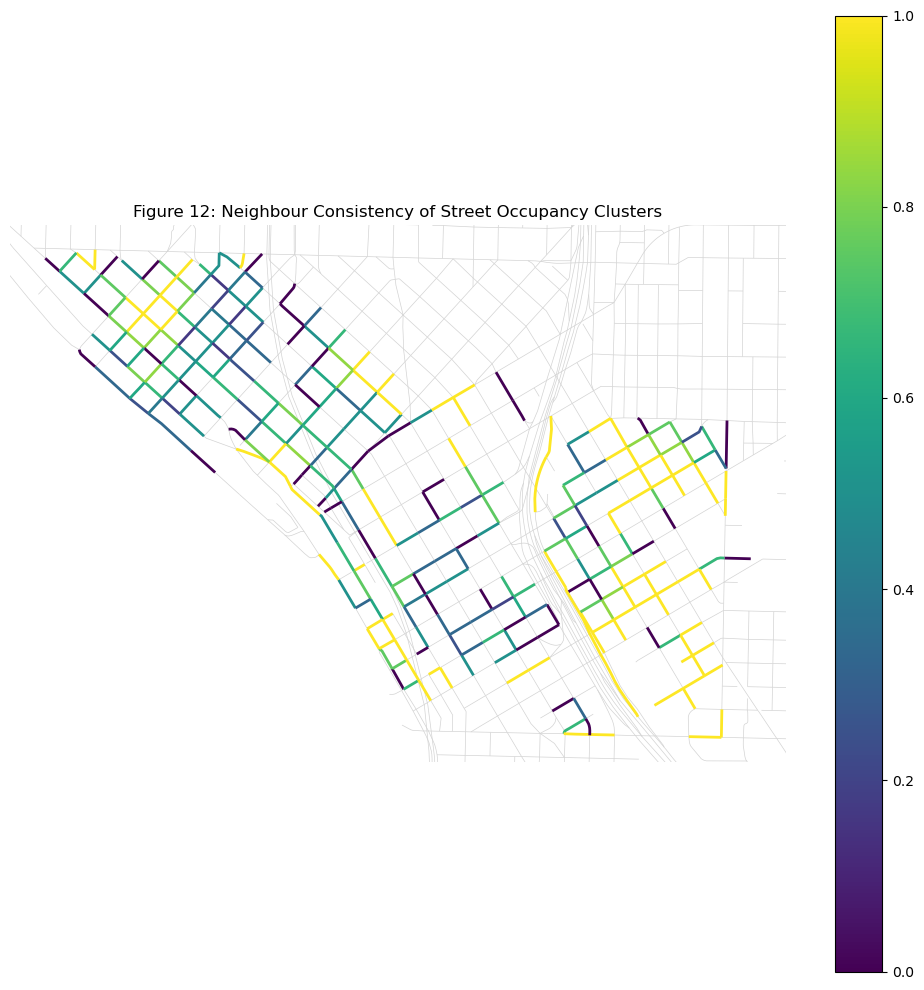

In [38]:
# 22.5. Mapping the ‘neighbourhood consistency rate’
fig, ax = plt.subplots(figsize=(10, 10))

plot_gdf = rq2_gdf.dropna(subset=["same_cluster_ratio"]).copy()

xmin, ymin, xmax, ymax = plot_gdf.total_bounds
xpad = (xmax - xmin) * 0.05
ypad = (ymax - ymin) * 0.05

streets_base.plot(ax=ax, color="lightgrey", linewidth=0.5)

plot_gdf.plot(
    ax=ax,
    column="same_cluster_ratio",
    linewidth=2,
    legend=True
)

ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

ax.set_title("Figure 12: Neighbour Consistency of Street Occupancy Clusters")
ax.axis("off")
plt.tight_layout()
plt.show()


#### 5.3 Factors and levels of influence

In [39]:
# RQ3. Impact factor analysis: constructing explanatory variables at street level
# Dependent variable: overall_mean_occupancy
# Method: Random Forest Regression + Permutation Importance

# 23. import additional data
paystations = pd.read_csv(PAY_STATIONS_CSV, low_memory=False)
streets_attr = pd.read_csv(STREETS_ATTR_CSV, low_memory=False)

paystations.columns = [c.strip().lower() for c in paystations.columns]
streets_attr.columns = [c.strip().lower() for c in streets_attr.columns]

parcels = gpd.read_file(PARCELS_SHP)
buildings = gpd.read_file(BUILDINGS_SHP)

parcels.columns = [c.strip().lower() for c in parcels.columns]
buildings.columns = [c.strip().lower() for c in buildings.columns]

if parcels.crs is None:
    parcels = parcels.set_crs("EPSG:4326")
if buildings.crs is None:
    buildings = buildings.set_crs("EPSG:4326")

parcels = parcels.to_crs(epsg=2285)
buildings = buildings.to_crs(epsg=2285)
streets_base = streets_base.to_crs(epsg=2285)

In [40]:
# 24. build 'street_y'
street_y = (
    street_occ_table.groupby(
        ["compkey", "unitdesc", "onstreet", "blockface_name"],
        dropna=True
    )
    .agg(
        overall_mean_occupancy=("occupancy_rate", "mean"),
        parking_spaces=("parking_spaces", "median"),
        mean_occupied_spaces=("occupied_spaces", "mean"),
        time_limit=("time_limit", mode_safe),
        parking_category=("parking_category", mode_safe),
        paid_subarea=("paid_subarea", mode_safe)
    )
    .reset_index()
)

print(street_y.head())

   compkey                                   unitdesc onstreet  \
0     1000   1ST AVE BETWEEN YESLER WAY AND CHERRY ST  1ST AVE   
1     1001  1ST AVE BETWEEN CHERRY ST AND COLUMBIA ST  1ST AVE   
2     1002  1ST AVE BETWEEN COLUMBIA ST AND MARION ST  1ST AVE   
3     1004   1ST AVE BETWEEN MADISON ST AND SPRING ST  1ST AVE   
4     1005    1ST AVE BETWEEN SPRING ST AND SENECA ST  1ST AVE   

                              blockface_name  overall_mean_occupancy  \
0   1ST AVE BETWEEN YESLER WAY AND CHERRY ST                0.388899   
1  1ST AVE BETWEEN CHERRY ST AND COLUMBIA ST                0.404055   
2  1ST AVE BETWEEN COLUMBIA ST AND MARION ST                0.391713   
3   1ST AVE BETWEEN MADISON ST AND SPRING ST                0.357802   
4    1ST AVE BETWEEN SPRING ST AND SENECA ST                0.393904   

   parking_spaces  mean_occupied_spaces  time_limit parking_category  \
0             8.0              3.131646         120     Paid Parking   
1             5.5         

In [41]:
# 25. price of pay station
paystations["elmntkey"] = pd.to_numeric(paystations["elmntkey"], errors="coerce")

price_cols = [
    "wkd_rate1", "wkd_rate2", "wkd_rate3",
    "sat_rate1", "sat_rate2", "sat_rate3",
    "sun_rate1", "sun_rate2", "sun_rate3"
]
for c in price_cols:
    if c in paystations.columns:
        paystations[c] = pd.to_numeric(paystations[c], errors="coerce")

paystations["weekday_rate_mean_station"] = paystations[
    [c for c in ["wkd_rate1", "wkd_rate2", "wkd_rate3"] if c in paystations.columns]
].mean(axis=1)

paystations["weekend_rate_mean_station"] = paystations[
    [c for c in ["sat_rate1", "sat_rate2", "sat_rate3", "sun_rate1", "sun_rate2", "sun_rate3"] if c in paystations.columns]
].mean(axis=1)

paystations["all_rate_mean_station"] = paystations[
    [c for c in price_cols if c in paystations.columns]
].mean(axis=1)

paystations["all_rate_max_station"] = paystations[
    [c for c in price_cols if c in paystations.columns]
].max(axis=1)

source_to_street["SourceElementKey"] = pd.to_numeric(source_to_street["SourceElementKey"], errors="coerce")

source_lookup = source_to_street[["SourceElementKey", "compkey"]].rename(
    columns={"compkey": "street_compkey"}
)

paystations_source = paystations.merge(
    source_lookup,
    left_on="elmntkey",
    right_on="SourceElementKey",
    how="left"
)

paystations_street = (
    paystations_source.dropna(subset=["street_compkey"])
    .groupby("street_compkey", dropna=True)
    .agg(
        paystation_count=("unitid", "nunique"),
        weekday_rate_mean_ps=("weekday_rate_mean_station", "mean"),
        weekend_rate_mean_ps=("weekend_rate_mean_station", "mean"),
        all_rate_mean_ps=("all_rate_mean_station", "mean"),
        all_rate_max_ps=("all_rate_max_station", "mean"),
        paidarea_ps=("paidarea", mode_safe),
        subarea_ps=("subarea", mode_safe)
    )
    .reset_index()
    .rename(columns={"street_compkey": "compkey"})
)


In [42]:
# 26. streets csv: Street morphology variables
streets_attr["compkey"] = pd.to_numeric(streets_attr["compkey"], errors="coerce")

study_compkeys = street_y["compkey"].dropna().unique()
streets_attr = streets_attr[
    streets_attr["compkey"].isin(study_compkeys)
].copy()

streets_attr["speedlimit"] = pd.to_numeric(streets_attr["speedlimit"], errors="coerce")
streets_attr["surfacewidth"] = pd.to_numeric(streets_attr["surfacewidth"], errors="coerce")
streets_attr["seglength"] = pd.to_numeric(streets_attr["seglength"], errors="coerce")
streets_attr["slope_pct"] = pd.to_numeric(streets_attr["slope_pct"], errors="coerce")
streets_attr["shape__length"] = pd.to_numeric(streets_attr["shape__length"], errors="coerce")

street_attr_final = (
    streets_attr.groupby("compkey", dropna=True)
    .agg(
        street_width=("surfacewidth", "mean"),
        speed_limit=("speedlimit", "mean"),
        seg_length=("seglength", "mean"),
        shape_length=("shape__length", "mean"),
        slope_pct=("slope_pct", "mean"),
        one_way=("oneway", mode_safe),
        artdescript=("artdescript", mode_safe)
    )
    .reset_index()
)


In [43]:
# 27. Research District Street buffer
street_geom = streets_base.merge(
    street_y[["compkey"]],
    on="compkey",
    how="inner"
).drop_duplicates(subset=["compkey"]).copy()

street_geom["buffer_geom"] = street_geom.geometry.buffer(BUFFER_DIST)

street_buffer = gpd.GeoDataFrame(
    street_geom[["compkey", "unitdesc", "onstreet"]],
    geometry=street_geom["buffer_geom"],
    crs=street_geom.crs
)

street_buffer["buffer_area"] = street_buffer.geometry.area

In [46]:
# 28. parcels land use
landuse_col = "land_use_d"

parcels_sub = parcels[[landuse_col, "geometry"]].dropna(subset=[landuse_col]).copy()

parcel_intersection = gpd.overlay(
    street_buffer,
    parcels_sub,
    how="intersection"
)

parcel_intersection["intersect_area"] = parcel_intersection.geometry.area
parcel_intersection["lu_raw"] = parcel_intersection[landuse_col].astype(str).str.lower().str.strip()

def simplify_landuse(x):
    x = str(x).lower().strip()

    if any(k in x for k in [
        "commercial", "retail", "restaurant", "office", "hotel", "mixed",
        "general commercial", "downtown office core", "commercial / mixed use"
    ]):
        return "commercial_mixed"
    elif any(k in x for k in [
        "residential", "single family", "single-family", "multifamily",
        "multi-family", "apartment", "condo", "townhouse", "household"
    ]):
        return "residential"
    elif any(k in x for k in ["industrial", "warehouse", "manufacturing"]):
        return "industrial"
    elif any(k in x for k in ["park", "open space", "recreation", "vacant", "green"]):
        return "open_space"
    elif any(k in x for k in [
        "institution", "institutional", "school", "government", "public",
        "hospital", "civic", "university", "college"
    ]):
        return "institutional"
    elif any(k in x for k in [
        "parking", "garage", "transport", "terminal", "street right-of-way",
        "right-of-way", "utility", "transportation"
    ]):
        return "transport_parking"
    else:
        return "other"

parcel_intersection["lu_group"] = parcel_intersection["lu_raw"].apply(simplify_landuse)

lu_area = (
    parcel_intersection.groupby(["compkey", "lu_group"], dropna=False)["intersect_area"]
    .sum()
    .reset_index()
)

lu_wide = lu_area.pivot_table(
    index="compkey",
    columns="lu_group",
    values="intersect_area",
    fill_value=0
).reset_index()

lu_cols = [c for c in lu_wide.columns if c != "compkey"]
lu_wide["lu_total_area"] = lu_wide[lu_cols].sum(axis=1)

for c in lu_cols:
    lu_wide[f"{c}_share"] = np.where(
        lu_wide["lu_total_area"] > 0,
        lu_wide[c] / lu_wide["lu_total_area"],
        0
    )

lu_share_cols = ["compkey"] + [f"{c}_share" for c in lu_cols]
lu_share = lu_wide[lu_share_cols].copy()

expected_lu_share_cols = [
    "commercial_mixed_share",
    "residential_share",
    "industrial_share",
    "institutional_share",
    "open_space_share",
    "transport_parking_share",
    "other_share"
]
for c in expected_lu_share_cols:
    if c not in lu_share.columns:
        lu_share[c] = 0.0


In [47]:
# 29. buildings: number of buildings and building coverage
buildings_sub = buildings[["geometry"]].copy()

building_intersection = gpd.overlay(
    street_buffer,
    buildings_sub,
    how="intersection"
)

building_intersection["bldg_intersect_area"] = building_intersection.geometry.area
building_intersection["bldg_count"] = 1

bldg_stats = (
    building_intersection.groupby("compkey")
    .agg(
        building_count=("bldg_count", "sum"),
        building_area_in_buffer=("bldg_intersect_area", "sum")
    )
    .reset_index()
)

bldg_stats = bldg_stats.merge(
    street_buffer[["compkey", "buffer_area"]],
    on="compkey",
    how="left"
)

bldg_stats["building_coverage_ratio"] = np.where(
    bldg_stats["buffer_area"] > 0,
    bldg_stats["building_area_in_buffer"] / bldg_stats["buffer_area"],
    np.nan
)


In [49]:
# 30. Consolidated into the RQ3 summary table
rq3_df = (
    street_y
    .merge(paystations_street, on="compkey", how="left")
    .merge(street_attr_final, on="compkey", how="left")
    .merge(lu_share, on="compkey", how="left")
    .merge(
        bldg_stats[["compkey", "building_count", "building_coverage_ratio"]],
        on="compkey",
        how="left"
    )
)

for c in expected_lu_share_cols + ["building_count", "building_coverage_ratio"]:
    if c in rq3_df.columns:
        rq3_df[c] = pd.to_numeric(rq3_df[c], errors="coerce").fillna(0)

print(rq3_df.head())
print(rq3_df.shape)

rq3_df.to_csv(f"{OUT_DIR}/{STUDY_NAME}_rq3_model_table_raw.csv", index=False)

   compkey                                   unitdesc onstreet  \
0     1000   1ST AVE BETWEEN YESLER WAY AND CHERRY ST  1ST AVE   
1     1001  1ST AVE BETWEEN CHERRY ST AND COLUMBIA ST  1ST AVE   
2     1002  1ST AVE BETWEEN COLUMBIA ST AND MARION ST  1ST AVE   
3     1004   1ST AVE BETWEEN MADISON ST AND SPRING ST  1ST AVE   
4     1005    1ST AVE BETWEEN SPRING ST AND SENECA ST  1ST AVE   

                              blockface_name  overall_mean_occupancy  \
0   1ST AVE BETWEEN YESLER WAY AND CHERRY ST                0.388899   
1  1ST AVE BETWEEN CHERRY ST AND COLUMBIA ST                0.404055   
2  1ST AVE BETWEEN COLUMBIA ST AND MARION ST                0.391713   
3   1ST AVE BETWEEN MADISON ST AND SPRING ST                0.357802   
4    1ST AVE BETWEEN SPRING ST AND SENECA ST                0.393904   

   parking_spaces  mean_occupied_spaces  time_limit parking_category  \
0             8.0              3.131646         120     Paid Parking   
1             5.5         

<div style="line-height: 2.0;">

**5.3.A Figure 13 | Distributions of Explanatory Variables by Cluster**

**Orange** and **blue** streets cluster more in higher-price, higher commercial-mix areas, while **green** streets are more common where commercial mix is lower; by contrast, the three types overlap much more in building coverage. 

Overall, parking price and commercial mix distinguish parking patterns better than building coverage.



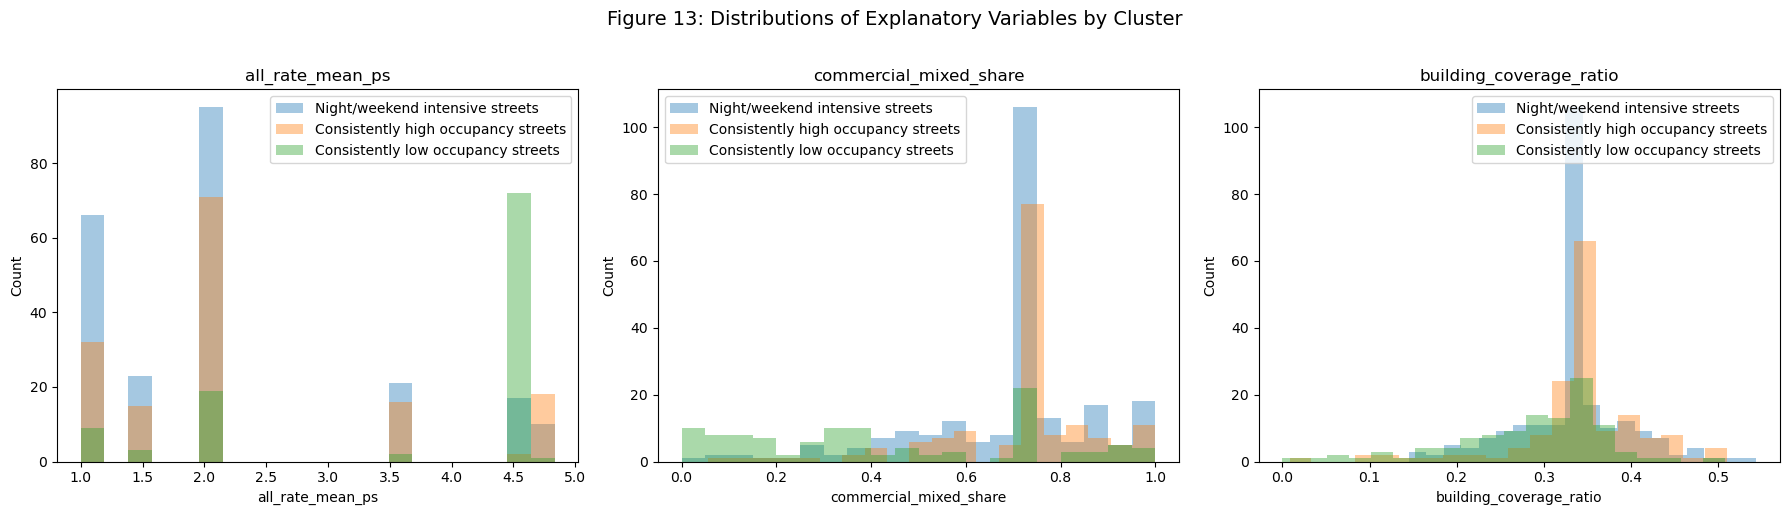

In [50]:
# 31. Cluster distributions of explanatory variables
rq3_cluster_df = rq3_df.merge(
    street_kmeans_result[["compkey", "cluster_label"]],
    on="compkey",
    how="left"
)

plot_vars_ext = [
    "all_rate_mean_ps",
    "commercial_mixed_share",
    "building_coverage_ratio"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, var in enumerate(plot_vars_ext):
    ax = axes[i]
    for label in rq3_cluster_df["cluster_label"].dropna().unique():
        rq3_cluster_df.loc[
            rq3_cluster_df["cluster_label"] == label, var
        ].dropna().plot(
            kind="hist",
            bins=20,
            alpha=0.4,
            ax=ax,
            label=label
        )
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Figure 13: Distributions of Explanatory Variables by Cluster", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [51]:
# 32. Prepare for modeling
target = "overall_mean_occupancy"

candidate_features = [
    "all_rate_mean_ps",
    "parking_spaces",
    "paystation_count",
    "street_width",
    "speed_limit",
    "building_coverage_ratio",
    "commercial_mixed_share",
    "residential_share",
    "transport_parking_share"
]

feature_cols = [c for c in candidate_features if c in rq3_df.columns]

categorical_cols = [
    c for c in ["one_way", "artdescript"] if c in rq3_df.columns
]

model_df = rq3_df[[target] + feature_cols + categorical_cols].copy()

for c in feature_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")
    model_df[c] = model_df[c].fillna(model_df[c].median())

for c in categorical_cols:
    model_df[c] = model_df[c].astype(str).replace("nan", "unknown").fillna("unknown")

model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)
model_df = model_df.dropna(subset=[target]).copy()

print(model_df.head())
print(model_df.shape)

model_df.to_csv(f"{OUT_DIR}/{STUDY_NAME}_rq3_model_table_final.csv", index=False)

   overall_mean_occupancy  all_rate_mean_ps  parking_spaces  paystation_count  \
0                0.388899          3.500000             8.0               2.0   
1                0.404055          3.500000             5.5               2.0   
2                0.391713          4.833333             6.0               2.0   
3                0.357802          4.833333             5.0               1.0   
4                0.393904          4.833333             7.5               2.0   

   street_width  speed_limit  building_coverage_ratio  commercial_mixed_share  \
0          44.0         25.0                 0.250286                0.625144   
1          52.0         25.0                 0.403185                0.356451   
2          52.0         25.0                 0.381442                0.891813   
3          52.0         25.0                 0.394410                0.553611   
4          52.0         25.0                 0.400751                0.771515   

   residential_share  tran

In [52]:
# 33. Random Forest
X = model_df.drop(columns=[target])
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

Train R2: 0.7277993261483748
Test R2: 0.2792639257654891
Test MAE: 0.12285567265415477


<div style="line-height: 2.0;">

The model captures the main patterns, but the gap between Train R² (0.728) and Test R² (0.279) suggests some overfitting, likely because city-centre parking occupancy is also shaped by unobserved factors such as activity types and locational differences. The MAE of 0.123 indicates an average prediction error of about 12 percentage points.

                            feature  importance_mean  importance_std
0                  all_rate_mean_ps         0.327510        0.081072
6            commercial_mixed_share         0.079088        0.055395
5           building_coverage_ratio         0.052155        0.047915
1                    parking_spaces         0.009463        0.011513
13   artdescript_Principal Arterial         0.003526        0.004325
11       artdescript_Minor Arterial         0.003218        0.003074
2                  paystation_count         0.001178        0.003020
12       artdescript_Not Designated         0.001117        0.002037
4                       speed_limit         0.000297        0.002225
14  artdescript_State Route/Freeway         0.000017        0.000055
10   artdescript_Interstate/Freeway         0.000000        0.000000
3                      street_width        -0.001234        0.009190
8           transport_parking_share        -0.001561        0.001245
9                         one_way_

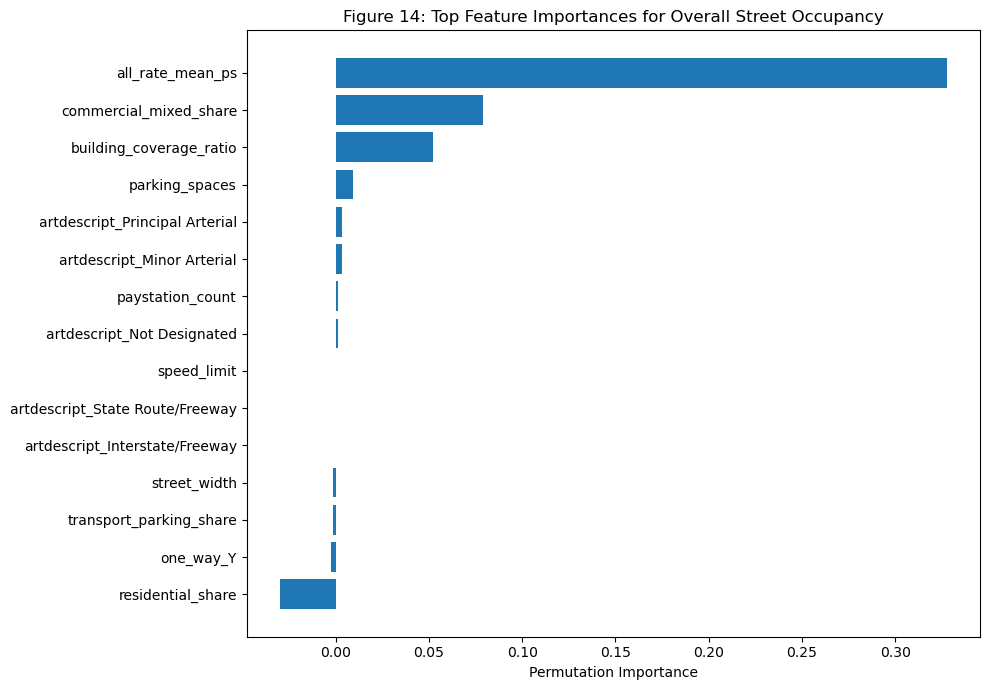

In [53]:
# 34. Permutation Importance
perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_df)

perm_df.to_csv(
    f"{RAW_DIR}/{STUDY_NAME}_rq3_permutation_importance_reduced.csv",
    index=False
)

top_n = min(15, len(perm_df))
plot_df = perm_df.head(top_n).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Permutation Importance")
plt.title("Figure 14: Top Feature Importances for Overall Street Occupancy")
plt.tight_layout()
plt.show()

<div style="line-height: 2.0;">

**5.3.C Figure 15 | PDPs**

These probability density functions (PDPs) indicate that there is a non-linear relationship between these three key variables and overall street usage. Although all_rate_mean_ps is the most significant variable (0.328), its influence is more variable; in contrast, commercial_mixed_share (0.079) and building_coverage_ratio (0.052) show a more pronounced positive correlation with predicted usage.

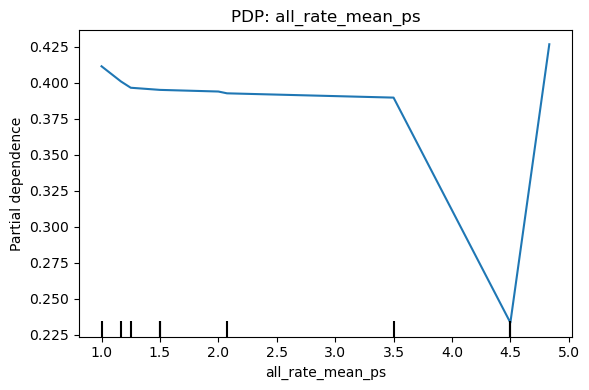

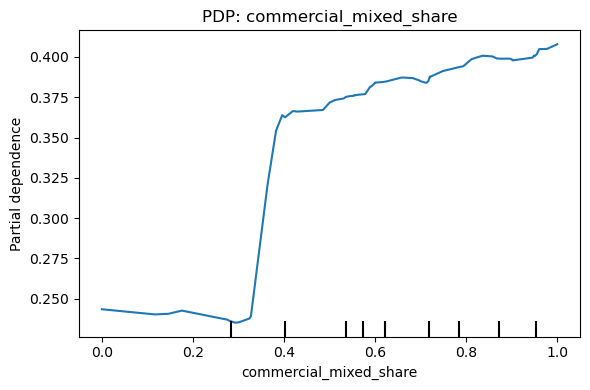

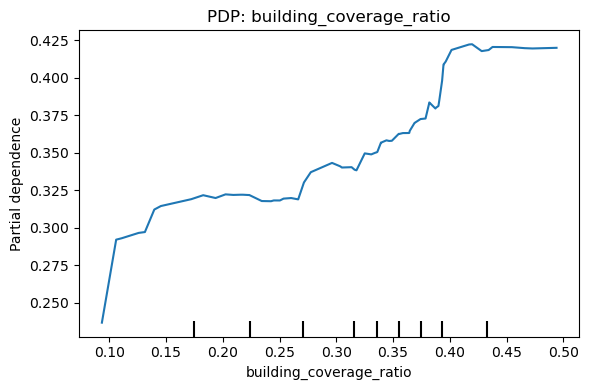

In [54]:
# 34. PDP
top_features = perm_df.head(3)["feature"].tolist()

for f in top_features:
    fig, ax = plt.subplots(figsize=(6, 4))
    PartialDependenceDisplay.from_estimator(
        rf,
        X_test,
        [f],
        ax=ax
    )
    ax.set_title(f"PDP: {f}")
    plt.tight_layout()
    plt.show()

<div style="line-height: 2.0;">

These three PDP plots indicate that the relationship between the three key variables and overall street occupancy is not simply linear. ‘all_rate_mean_ps’ has the highest significance (0.328), but its trend fluctuates considerably, suggesting that price exerts the strongest influence but operates through the most complex mechanism; by contrast, ‘commercial_mixed_share’ (0.079) and ‘building_coverage_ratio’ (0.052) both exhibit a clearer positive trend, meaning that higher commercial mix and building coverage are associated with higher predicted overall occupancy rates.

In [56]:
print(f"Total runtime: {(time.time() - start_time)/60:.2f} minutes")

Total runtime: 0.32 minutes


## 6.0 
## Conclusion

[[ go back to the top ]](#Table-of-contents)

<div style="line-height: 2.0;">

This study indicates that on-street paid parking in downtown Seattle exhibits significant temporal and spatial variation. Most streets remain undersaturated across all four time periods, although occupancy rates are generally higher on weekend nights. 

K-means clustering further identified three categories of streets: consistently low-occupancy, night-time/weekend-intensive, and consistently high-occupancy. These categories are not randomly distributed but exhibit a certain degree of spatial clustering; streets with consistently low occupancy show the strongest clustering, whilst those with consistently high occupancy are relatively more dispersed. An analysis of influencing factors revealed that parking prices are the most critical variable in explaining overall occupancy differences, followed by the proportion of mixed-use commercial land and building coverage. 

Overall, on-street parking occupancy in the city centre is primarily influenced by a combination of pricing mechanisms, the intensity of commercial activity and the density of the built environment. Consequently, parking management should adopt differentiated strategies that are more time- and location-specific.